In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ===== 入力パス（ご指定の場所） =====
data_files = [
    r"E:\refit\estimated_ch4_ppm_slice111_121.csv",
    # ここに他のCSVも追加してください（サイズは同じ前提）
    # r"E:\refit\estimated_ch4_ppm_slice122_132.csv",
]
mask_path = r"E:\tools\thesis\line_mask_grid.csv"


def load_csv_matrix(path: str) -> np.ndarray:
    """ヘッダ無し前提でCSVを2次元配列として読む（ヘッダがあっても壊れにくい）"""
    return pd.read_csv(path, header=None).to_numpy()


# ===== マスク読み込み（1のところを除外） =====
mask = load_csv_matrix(mask_path)
mask_bool = (mask == 1)  # True の画素を除外

# ===== 表示用カラーマップ（除外部分は透明） =====
cmap = plt.cm.viridis.copy()
cmap.set_bad((0, 0, 0, 0))  # RGBA: 透明

for f in data_files:
    z = load_csv_matrix(f)
    if z.shape != mask_bool.shape:
        raise ValueError(f"shapeが一致しません: data={z.shape}, mask={mask_bool.shape} ({f})")

    # 除外画素をマスクにする（表示しない）
    z_masked = np.ma.array(z, mask=mask_bool)

    # 除外以外の画素だけで表示レンジを決める（外れ値に強い）
    valid = z[~mask_bool]
    vmin, vmax = np.nanpercentile(valid, [2, 98])  # 好みで変更OK（例: [1,99] や min/max）

    plt.figure(figsize=(6, 5))
    im = plt.imshow(z_masked, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    plt.title(Path(f).name)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # 画像として保存したい場合（PNGで透明保持）
    # out_png = Path(f).with_suffix(".png")
    # plt.imsave(out_png, z_masked, cmap=cmap, vmin=vmin, vmax=vmax)


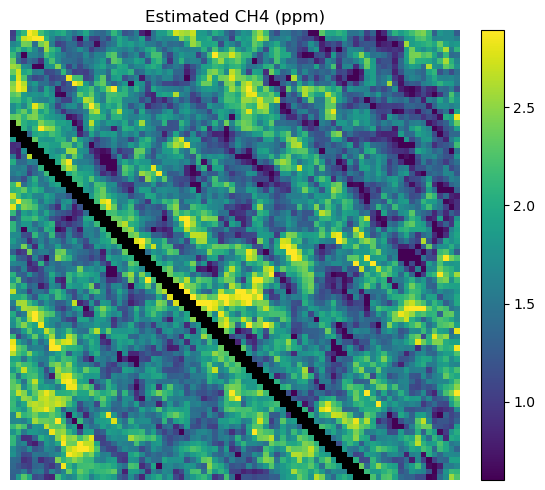

<Figure size 640x480 with 0 Axes>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ===== 入力パス（ご指定の場所） =====
data_files = [
    r"E:\refit\estimated_ch4_ppm_slice57_65.csv",
    # ここに他のCSVも追加してください（サイズは同じ前提）
    # r"E:\refit\estimated_ch4_ppm_slice122_132.csv",
]
mask_path = r"E:\tools\thesis\line_mask_grid.csv"


def load_csv_matrix(path: str) -> np.ndarray:
    """ヘッダ無し前提でCSVを2次元配列として読む（ヘッダがあっても壊れにくい）"""
    return pd.read_csv(path, header=None).to_numpy()


# ===== マスク読み込み（1のところを除外） =====
mask = load_csv_matrix(mask_path)
mask_bool = (mask == 1)  # True の画素を除外

# ===== 表示用カラーマップ（除外部分は透明） =====
cmap = plt.cm.viridis.copy()
cmap.set_bad((0, 0, 0, 1))  # RGBA: 透明

for f in data_files:
    z = load_csv_matrix(f)
    if z.shape != mask_bool.shape:
        raise ValueError(f"shapeが一致しません: data={z.shape}, mask={mask_bool.shape} ({f})")

    # 除外画素をマスクにする（表示しない）
    z_masked = np.ma.array(z, mask=mask_bool)

    # 除外以外の画素だけで表示レンジを決める（外れ値に強い）
    valid = z[~mask_bool]
    vmin, vmax = np.nanpercentile(valid, [2, 99])  # 好みで変更OK（例: [1,99] や min/max）

    plt.figure(figsize=(6, 5))
    im = plt.imshow(z_masked, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    plt.title("Estimated CH4 (ppm)")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # 画像として保存したい場合（PNGで透明保持）
    # out_png = Path(f).with_suffix(".png")
    # plt.imsave(out_png, z_masked, cmap=cmap, vmin=vmin, vmax=vmax)
    out_eps = Path(f).with_suffix(".png")
    plt.savefig(out_eps, format="png", bbox_inches="tight", pad_inches=0)
